In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import jaxfilter, jaxfixedpt
from scipy import signal
import jax
import jax.numpy as jnp
# Force JAX to use float64 for better numerical agreement
jax.config.update("jax_enable_x64", True)

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "lms-based"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
  path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
  if tight_layout:
      plt.tight_layout()
  plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

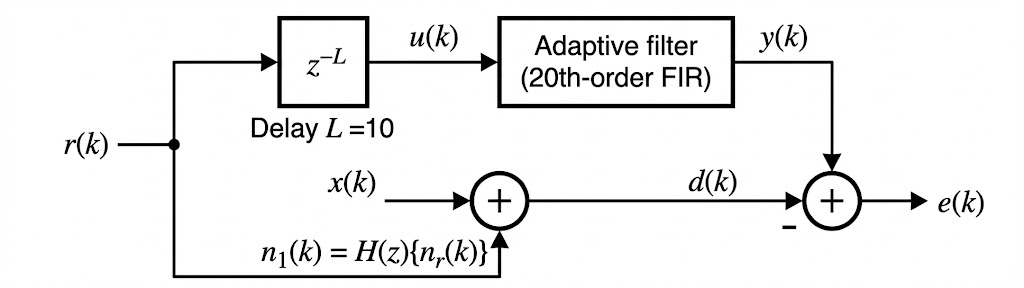
In a signal enhancement problem, the reference signal is $r(k)=\sin(0.2 \pi k) + n_r(k)$ 

* $n_r (k)$ is zero-mean Gaussian white noise with variance $σ^2_{n_r} = 10$ and pass through a filter with transfer function $H(z)=0.4/(z^2-1.36z+0.79)$
* The adaptive filter is a 20th-order FIR filter. In all examples, a delay $L = 10$ is applied to the reference signal.
* 
1. Target Signal (Clean Signal)The clean signal we wish to recover is a discrete-time sine wave:$$x(k) = \sin(0.2\pi k)$$
2. Reference SignalThe reference signal $r(k)$ consists of the clean signal corrupted by additive white Gaussian noise (AWGN):$$r(k) = x(k) + n_r(k)$$Noise Characteristics: $n_r(k)$ is zero-mean Gaussian white noise with variance $\sigma^2_{n_r} = 10$.
3. Interference Path (Noise Filter)The noise in the primary channel is a filtered version of the reference noise. The transfer function of the interference path is:$$H(z) = \frac{0.4}{z^2 - 1.36z + 0.79}$$
4. Desired Signal (Primary Input)The desired signal $d(k)$ contains the target clean signal and a filtered noise component $n_1(k)$:$$d(k) = x(k) + n_1(k)$$where the interference $n_1(k)$ is generated by passing the reference noise through the interference path:$$n_1(k) = H(z) \{n_r(k)\}$$Note: The interference component $n_1(k)$ originates only from the noise $n_r(k)$, not from the entire reference signal $r(k)$.
5. Adaptive Filter SetupThe adaptive filter aims to minimize the error between its output and the desired signal.Filter Type: 20th-order FIR Filter.Input Signal $u(k)$: The reference signal is delayed by $L = 10$ samples before entering the filter:$$u(k) = r(k - L), \quad L = 10$$

In [3]:
def trainSeqsSigEnhance(
    n_samples,
    key,
    h,
    sigma_nr2=10.0,
    dly_L=10,
):
  key, k_nr = jax.random.split(key)
  total = n_samples + dly_L
  k = jnp.arange(total)

  # clean signal
  x_clean = jnp.sin(0.2 * jnp.pi * k)

  # reference noise
  n_r = jax.random.normal(k_nr, (total,)) * jnp.sqrt(sigma_nr2)

  # reference signal
  r = x_clean + n_r

  # interference path acts ONLY on noise
  n1 = jnp.convolve(n_r, h, mode="full")[:total]

  # desired signal
  d = x_clean + n1

  # delay reference
  u = r[:-dly_L]
  d = d[dly_L:]
  x_clean = x_clean[dly_L:]

  return u, d, x_clean


In [4]:
def runOnce(filter_model, u, d, key):
  variables = filter_model.init(key, u, d)
  (y, e, _), _ = filter_model.apply(
      variables, u, d, train=True, mutable=["state"]
  )
  return y, e

def runEnsemble(filter_model, n_samples, n_ensemble, h, sigma_nr2=10.0, dly_L=10, ret_lastrun=False):
  key = jax.random.PRNGKey(0)
  mse_accum = jnp.zeros(n_samples)
  # Store one example signal from the last ensemble run
  rets = {
    'desired': None,
    'input': None,
    'output': None,
    'error': None
  }
  for ens in range(n_ensemble):
    key, sub = jax.random.split(key)

    u, d, x = trainSeqsSigEnhance(
        n_samples=n_samples,
        key=sub,
        h=h,
        sigma_nr2=sigma_nr2,
        dly_L=dly_L,
    )

    y, e = runOnce(filter_model, u, d, sub)   # e.shape = (Ne,)

    Ne = e.shape[0]
    mse_accum = mse_accum.at[:Ne].add(jnp.abs(e) ** 2)
    if ret_lastrun and ens == n_ensemble - 1:
      # Store the last run for visualization
      rets['desired'] = x
      rets['input'] = d
      rets['output'] = y
      rets['error'] = e
  if ret_lastrun:
    return rets, mse_accum / n_ensemble
  else:
    return mse_accum / n_ensemble


In [5]:
n_samples = 700
n_ensemble = 20
nlms_mu_n = 0.02
filter_ord = 20
filters = {
  "LMS": jaxfilter.LMS(mu=0.001, filter_order=filter_ord),
  "NLMS": jaxfilter.NLMS(mu=nlms_mu_n, tau=1e-3, filter_order=filter_ord),
  "APA (P=1)": jaxfilter.AffineProjection(mu=0.5, P=1, delta=1e-3, filter_order=filter_ord),
  "APA (P=2)": jaxfilter.AffineProjection(mu=0.5, P=2, delta=1e-3, filter_order=filter_ord),

  "SignError": jaxfilter.SignErrorLMS(mu=0.02, filter_order=filter_ord),
  "SignData": jaxfilter.SignDataLMS(mu=0.02, filter_order=filter_ord),
  "SignSign": jaxfilter.SignSignLMS(mu=0.02, filter_order=filter_ord),

  "TD-DCT": jaxfilter.TransformDomain(mu=0.02, alpha=0.01, gamma=1e-8,
                                      matrix="dct", filter_order=filter_ord),
  "TD-DFT": jaxfilter.TransformDomain(mu=0.02, alpha=0.01, gamma=1e-8,
                                        matrix="dft", filter_order=filter_ord),
}

In [6]:
import scipy.signal as sig

b = jnp.array([0.4])
a = jnp.array([1.0, -1.36, 0.79])

# truncate impulse response
h = jnp.asarray(sig.lfilter(b, a, jnp.r_[1.0, jnp.zeros(50)]))

Running LMS ...
Running NLMS ...
Running APA (P=1) ...
Running APA (P=2) ...
Running SignError ...
Running SignData ...
Running SignSign ...
Running TD-DCT ...
Running TD-DFT ...


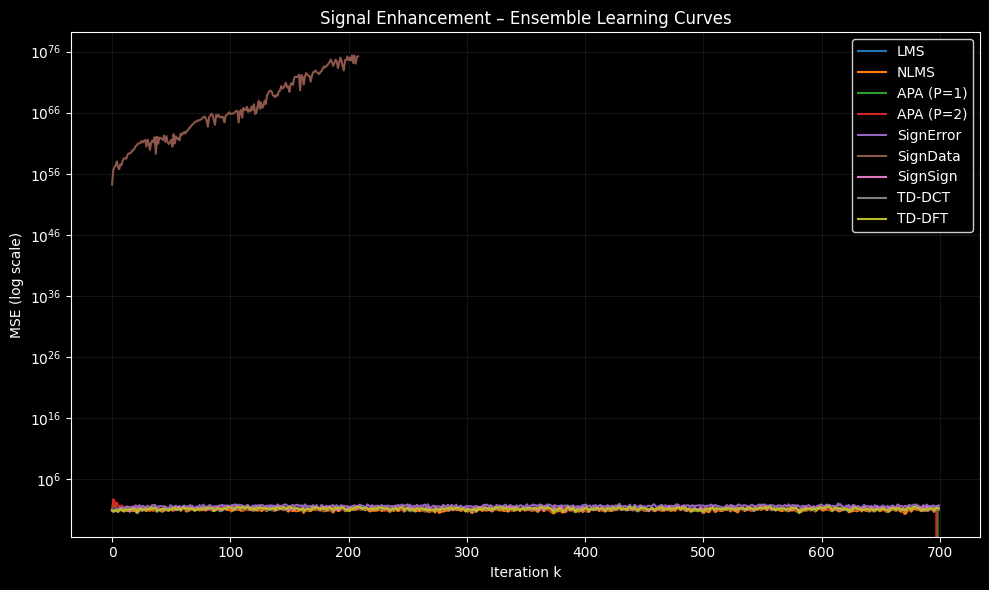

In [7]:
plt.figure(figsize=(10, 6))

for name, filt in filters.items():
  print(f"Running {name} ...")
  mse = runEnsemble(
      filt,
      n_samples=n_samples,
      n_ensemble=n_ensemble,
      h=h
  )
  plt.semilogy(mse, label=name)

plt.xlabel("Iteration k")
plt.ylabel("MSE (log scale)")
plt.title("Signal Enhancement – Ensemble Learning Curves")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# since Sign-Data LMS diverges in signal enhancement due to loss of second-order statistics.
# remove it from simulation and run again ...
del filters["SignData"]

In [8]:
def collectEnsResults(filters, n_samples, n_ensemble, h):
  results = {}

  for name, filt in filters.items():
      print(f"Running {name} ...")
      signals, mse = runEnsemble(
          filt,
          n_samples=n_samples,
          n_ensemble=n_ensemble,
          h=h,
          ret_lastrun=True
      )
      results[name] = {
          "signals": signals,
          "mse": np.asarray(mse)
      }
  return results
def pltLearningCurves(results, n_samples):
  plt.subplot(2, 2, (1, 2))

  for name, res in results.items():
    plt.semilogy(res["mse"], label=name, linewidth=2)

  plt.xlabel("Iteration k")
  plt.ylabel("MSE (log scale)")
  plt.title("Signal Enhancement – Ensemble Learning Curves")
  plt.grid(True, which="both", alpha=0.3)
  plt.legend(loc="upper right")
  plt.xlim([0, n_samples])
  
def pltTimeDomain(results, segment, highlight_filters):
  plt.subplot(2, 2, 3)

  ref = next(iter(results.values()))["signals"]
  desired = np.asarray(ref["desired"])
  noisy = np.asarray(ref["input"])

  plt.plot(desired[segment], label="Desired", linewidth=2)
  plt.plot(noisy[segment], "--", label="Noisy Input", alpha=0.5)

  for name in highlight_filters:
    if name in results:
      enhanced = np.real(np.asarray(results[name]["signals"]["output"]))
      plt.plot(enhanced[segment], label=name, linewidth=1.5)

  plt.xlabel("Sample index")
  plt.ylabel("Amplitude")
  plt.title("Enhanced Signals (Zoomed)")
  plt.grid(True, alpha=0.3)
  plt.legend(fontsize="small")
  
def pltErrSignals(results, segment, error_filters):
    plt.subplot(2, 2, 4)

    for name in error_filters:
      if name in results:
        sig = results[name]["signals"]
        desired = np.asarray(sig["desired"])
        enhanced = np.real(np.asarray(sig["output"]))
        error = desired[:len(enhanced)] - enhanced
        plt.plot(error[segment], label=f"{name} Error", linewidth=1.5)

    plt.axhline(0, color="k", alpha=0.3)
    plt.xlabel("Sample index")
    plt.ylabel("Error")
    plt.title("Error Signals")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize="small")
  
def computeMetrics(results, steady_state_start=50):
    print("\n" + "="*70)
    print("FILTER PERFORMANCE METRICS (Last Ensemble Run)")
    print("="*70)
    print(f"{'Filter':<12} {'Final MSE':<12} {'SS MSE':<12} "
          f"{'SNR Imp (dB)':<12} {'Error Std':<12}")
    print("-"*60)

    for name, res in results.items():
      sig = res["signals"]
      if sig["desired"] is None:
        continue

      desired = np.asarray(sig["desired"])
      enhanced = np.real(np.asarray(sig["output"]))
      noisy = np.asarray(sig["input"])

      N = len(enhanced)
      error = desired[:N] - enhanced

      ss = slice(steady_state_start, None)

      final_mse = np.mean(error[-steady_state_start:]**2)
      ss_mse = np.mean(error[ss]**2)
      err_std = np.std(error[ss])

      input_noise = noisy[:N] - desired[:N]
      input_snr = 10*np.log10(np.var(desired[ss]) / np.var(input_noise[ss]))
      output_snr = 10*np.log10(np.var(desired[ss]) / np.var(error[ss]))
      snr_imp = output_snr - input_snr

      print(f"{name:<12} {final_mse:>10.6f}   {ss_mse:>10.6f}   "
            f"{snr_imp:>+7.2f}        {err_std:>7.4f}")


In [9]:
def runAndVisualizeSignalEnhancement(
  filters,
  h,
  n_samples=700,
  n_ensemble=20,
  segment=slice(200, 250),
  highlight_filters=("NLMS", "TD-DCT", "TD-DFT", "LMS"),
  error_filters=("NLMS", "TD-DCT", "TD-DFT"),
):
  results = collectEnsResults(filters, n_samples, n_ensemble, h)

  plt.figure(figsize=(14, 8))
  pltLearningCurves(results, n_samples)
  pltTimeDomain(results, segment, highlight_filters)
  pltErrSignals(results, segment, error_filters)
  plt.tight_layout()
  plt.show()

  computeMetrics(results)

Running LMS ...
Running NLMS ...
Running APA (P=1) ...
Running APA (P=2) ...
Running SignError ...
Running SignSign ...
Running TD-DCT ...
Running TD-DFT ...


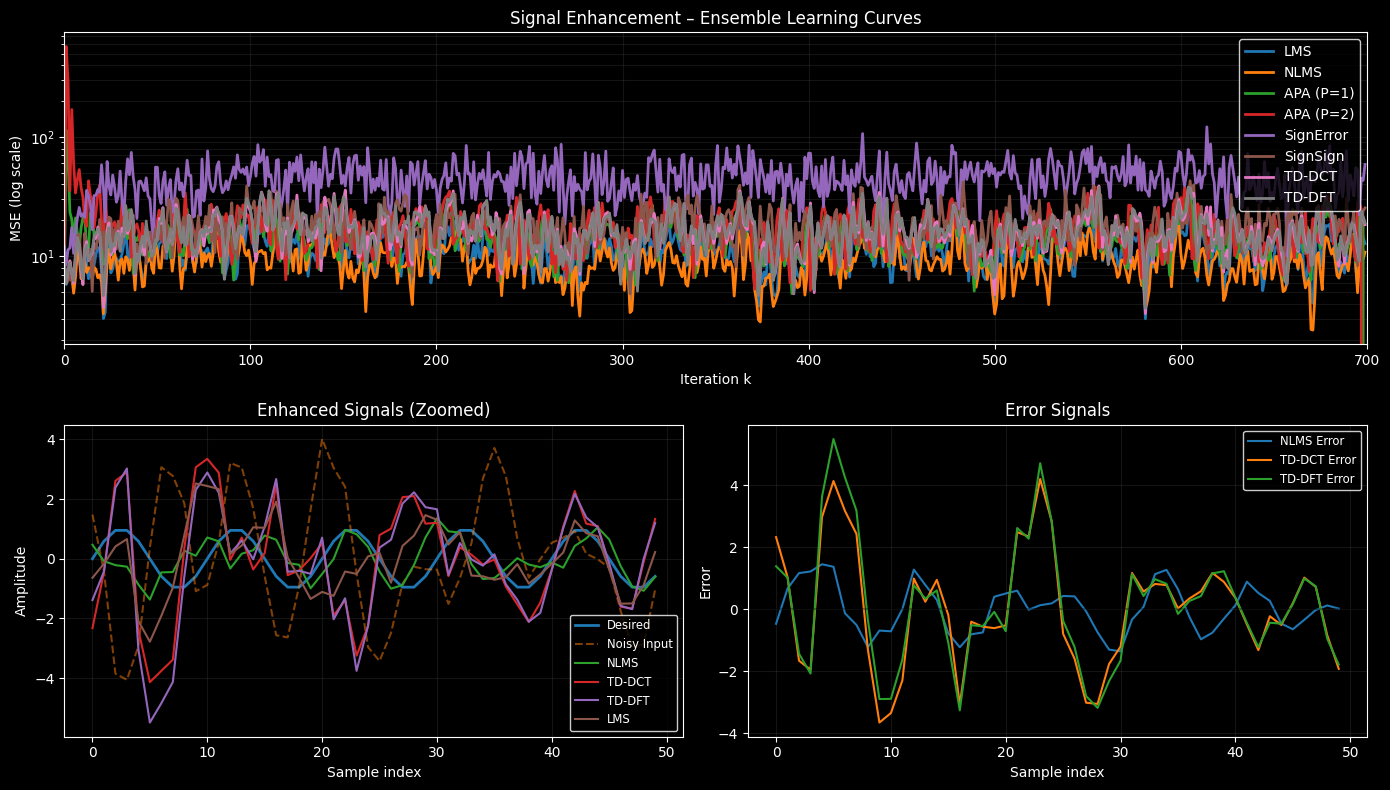


FILTER PERFORMANCE METRICS (Last Ensemble Run)
Filter       Final MSE    SS MSE       SNR Imp (dB) Error Std   
------------------------------------------------------------
LMS            1.977279     4.402970     +3.69         2.0983
NLMS           0.727840     0.830507    +10.93         0.9112
APA (P=1)      3.686137     8.366177     +0.92         2.8871
APA (P=2)      6.272447    11.448985     -0.42         3.3721
SignError     46.781166    40.345124     -5.93         6.3505
SignSign       8.539121    11.152717     -0.35         3.3394
TD-DCT         7.824830    10.287509     +0.00         3.2074
TD-DFT         7.786520     9.981103     +0.14         3.1591


In [10]:
runAndVisualizeSignalEnhancement(
  filters, h=h
)